# Exercises for Section 3.1 Estimates and estimators

This notebook contains the solutions to the exercises
from [Section 3.1 Estimates and estimators]()
in the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy scipy seaborn pandas ministats


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
)
%config InlineBackend.figure_format = "retina"

<Figure size 640x480 with 0 Axes>

In [4]:
# Simplified int and float __repr__
import numpy as np
np.set_printoptions(legacy='1.25')

In [5]:
# Pandas display options
pd.set_option("display.precision", 2)

In [6]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


## Exercises 1


### E3.1

Compute the sample mean from Batch 01 and Batch 04 of the kombucha dataset `datasets/kombucha.csv` .

In [8]:
# Load the kombucha dataset
kombucha = pd.read_csv("datasets/kombucha.csv")

# Select the volume measurements from Batch 04
ksample04 = kombucha[kombucha["batch"]==4]["volume"]

# Compute the mean volume in Batch 04
ksample04.mean()  # = mean(ksample04)

1003.8335

### E3.2

Compute the sample variance from Batch 02 and Batch 08 of the kombucha dataset `datasets/kombucha.csv`.

In [10]:
# Load the kombucha dataset
kombucha = pd.read_csv("datasets/kombucha.csv")

# Select Batch 02 from the kombucha dataset
ksample02 = kombucha[kombucha["batch"]==2]["volume"]

# Compute its variance
ksample02.var()  # = var(ksample02)

124.31760105263139

In [12]:
# Select Batch 08 from the kombucha dataset
ksample08 = kombucha[kombucha["batch"]==8]["volume"]

# Compute its variance
ksample08.var()

169.99792205128236

### E3.3

Compute the difference between the means of the sleep `score`s 
for the doctors working in `rur`al and `urb`an locations
in the doctors dataset `datasets/doctors.csv`.

Hint: Use the code `doctors[doctors["loc"]=="rur"]` to select
the subset of the doctors working in a `rural` location.

In [14]:
# Load the doctors dataset
doctors = pd.read_csv("datasets/doctors.csv")

# Select doctors from "rur" location and get the `score` variable
scoresR = doctors[doctors["loc"]=="rur"]["score"]

# Select doctors from "urb" location and get the `score` variable
scoresU = doctors[doctors["loc"]=="urb"]["score"]

# Compute difference between mean scores
scoresR.mean() - scoresU.mean()

6.992885375494076

In [15]:
# ALT.
# Define the `dmeans` estimator function
def dmeans(xsample, ysample):
    dhat = np.mean(xsample) - np.mean(ysample)
    return dhat

# Call `dmeans` to compute difference between mean scores
dmeans(scoresR, scoresU)

6.992885375494076

## Exercises 2


### E3.4

Generate $N=10000$ observations from the sampling distribution of the estimator `std` for samples of size $n=20$ from the population $K \sim \mathcal{N}(1000,10)$ .
Plot a histogram.

In [16]:
# Define the standard deviation estimator function
def std(sample):
    xbar = sum(sample) / len(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return np.sqrt(sumsqdevs / (len(sample)-1))

# Create a computer model for the kombucha population
from scipy.stats import norm
muK = 1000   # population mean
sigmaK = 10  # population standard deviation
rvK = norm(muK, sigmaK)

In [19]:
from ministats import gen_sampling_dist

# Set the random seed to a particular value to get a reproducible result
np.random.seed(42)

# Generate observations from the sampling distribution of `std`
kstds20 = gen_sampling_dist(rvK, estfunc=std, n=20, N=10000)
kstds20[0:5]

[9.60028421439027,
 9.680387092176915,
 8.208476944118853,
 11.120875642249183,
 6.908107201543384]

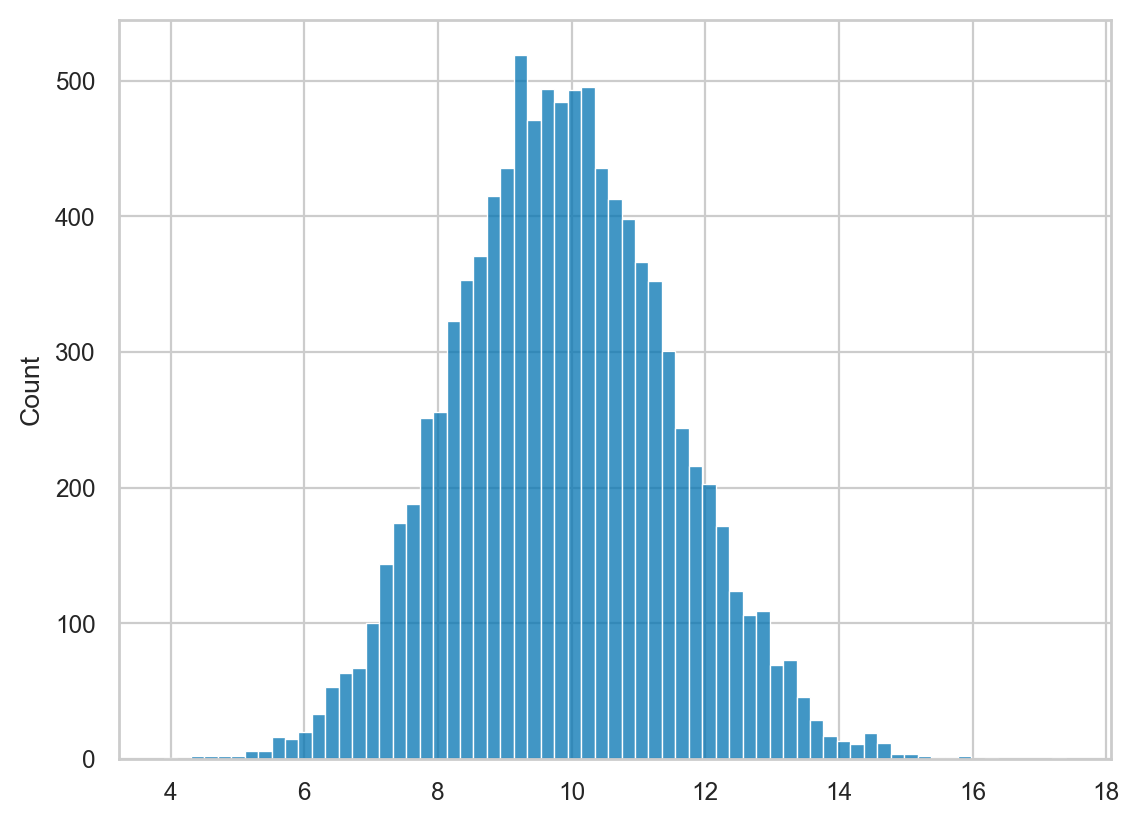

In [20]:
import seaborn as sns
# Plot histogram of the sampling distribution `kstds20`
sns.histplot(kstds20);

### E3.5

Generate the sampling distributions of the estimator `mean` for samples of size $n=10$ , $n=30$ , and $n=100$ from the population `rvK`  $= K \sim \mathcal{N}(1000,10)$ .
Plot a histogram for each distribution.
Plot also the probability density function of the normal approximations
predicted by the central limit theorem for each case.

In [21]:
# Create a computer model for the kombucha population
from scipy.stats import norm
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

In [23]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(43)

# Simulations of `xbars` for different sample sizes
xbars10 = gen_sampling_dist(rvK, estfunc=np.mean, n=10)
xbars30 = gen_sampling_dist(rvK, estfunc=np.mean, n=30)
xbars100 = gen_sampling_dist(rvK, estfunc=np.mean, n=100)

3.1344252181165833

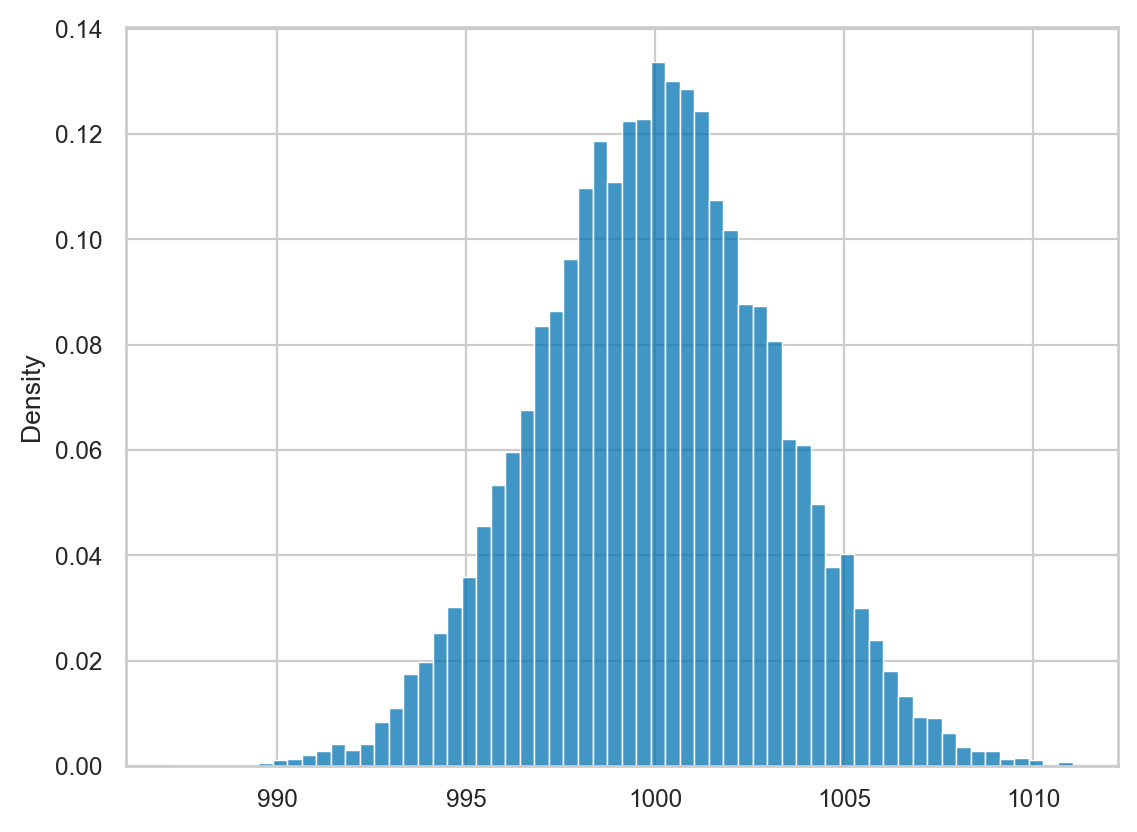

In [25]:
# Plot the histogram obtained from the n = 10 simulation
sns.histplot(xbars10, stat="density")

# Compute the standard deviation of the sampling distribution
np.std(xbars10)

1.8051604416489098

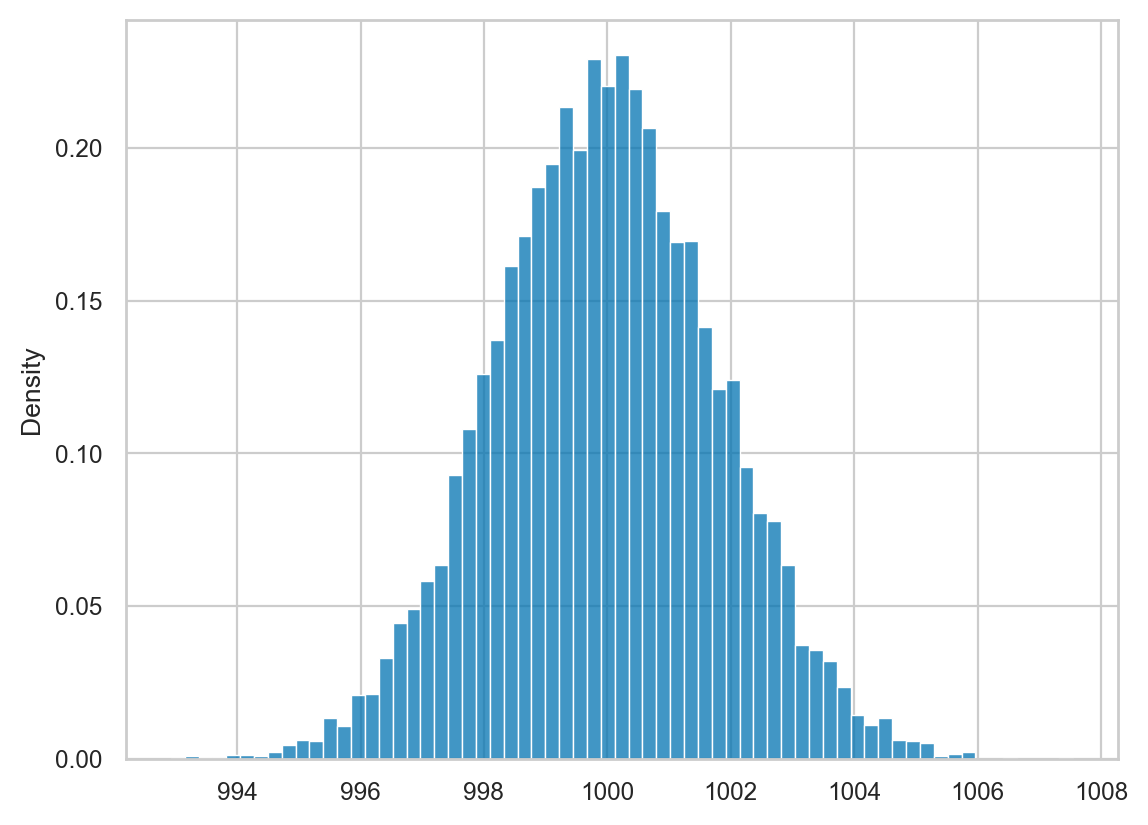

In [27]:
# Plot the histogram obtained from the n = 30 simulation
sns.histplot(xbars30, stat="density")

# Compute the standard deviation of the sampling distribution
np.std(xbars30)

0.9982856344634795

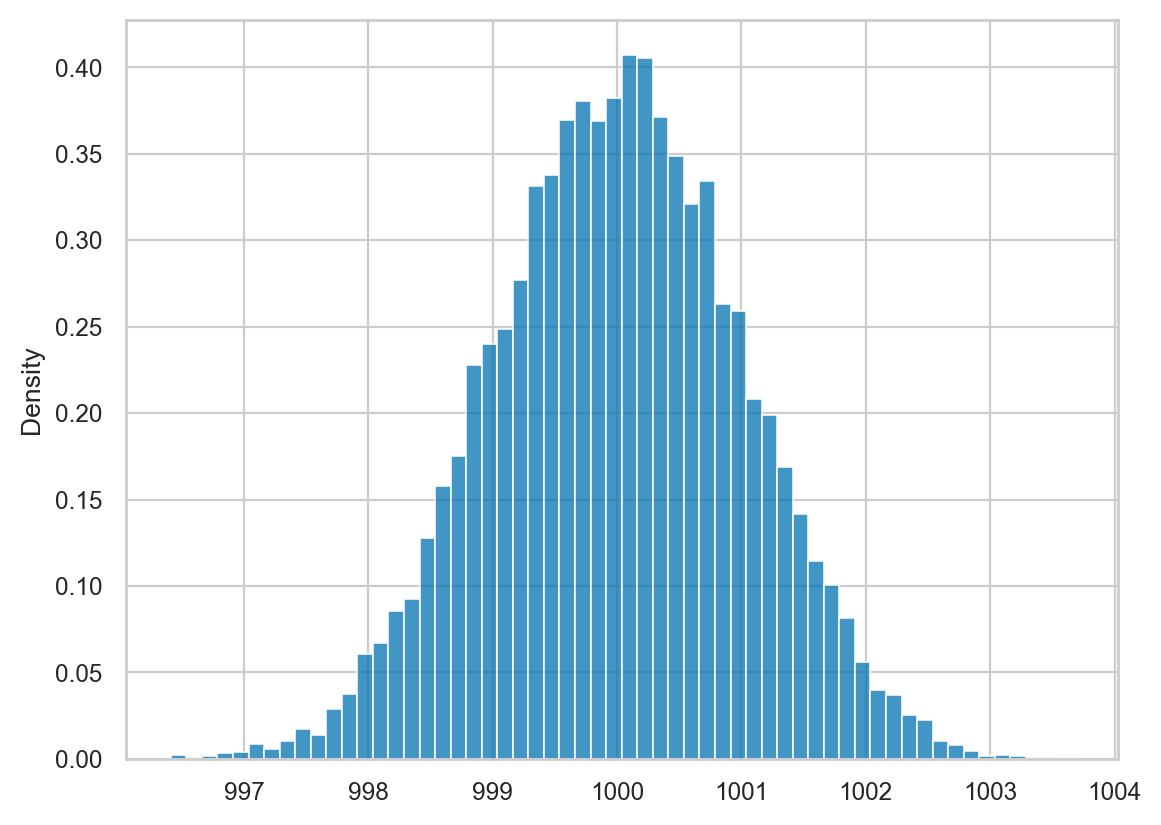

In [29]:
# Plot the histogram obtained from the n = 100 simulation
sns.histplot(xbars100, stat="density")

# Compute the standard deviation of the sampling distribution
np.std(xbars100)

### E3.6

Generate sampling distribution of the mean for samples of size $n=30$ from the standard uniform model $U \sim \mathcal{U}(0,1)$ .
Plot a histogram.

In [30]:
# Create a computer model for the standard uniform
from scipy.stats import uniform
rvU = uniform(0,1)

0.053696970885011554

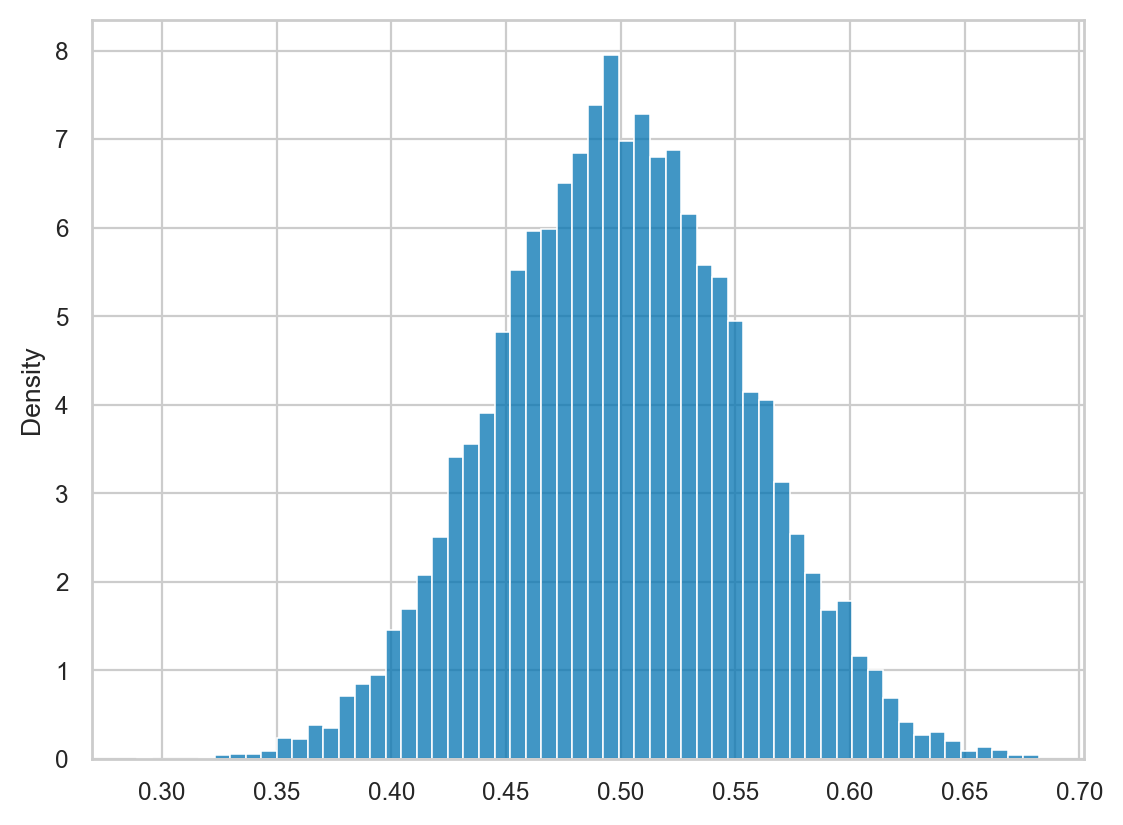

In [32]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(44)

# Simulate sampling distribution for samples of size n = 30
ubars30 = gen_sampling_dist(rvU, estfunc=np.mean, n=30)

# Plot the histogram obtained from simulation
sns.histplot(ubars30, stat="density")

# Compute the standard error (standard deviation of the sampling distribution)
np.std(ubars30)

## Exercises 3

### E3.7

Use the apples dataset
[`datasets/apples.csv`](https://noBSstats.com/datasets/apples.csv)
and bootstrap estimation
to approximate the sampling distribution of the mean for samples of size $n=30$ from the apples population.
Calculate the standard error $\stderrhat{\overline{\mathbf{a}}}$.
Based on your result,
describe the accuracy of the estimate $\overline{\mathbf{a}} = 202.6$
for the unknown population mean $\mu_A$.

In [33]:
apples = pd.read_csv("datasets/apples.csv")
asample = apples["weight"]

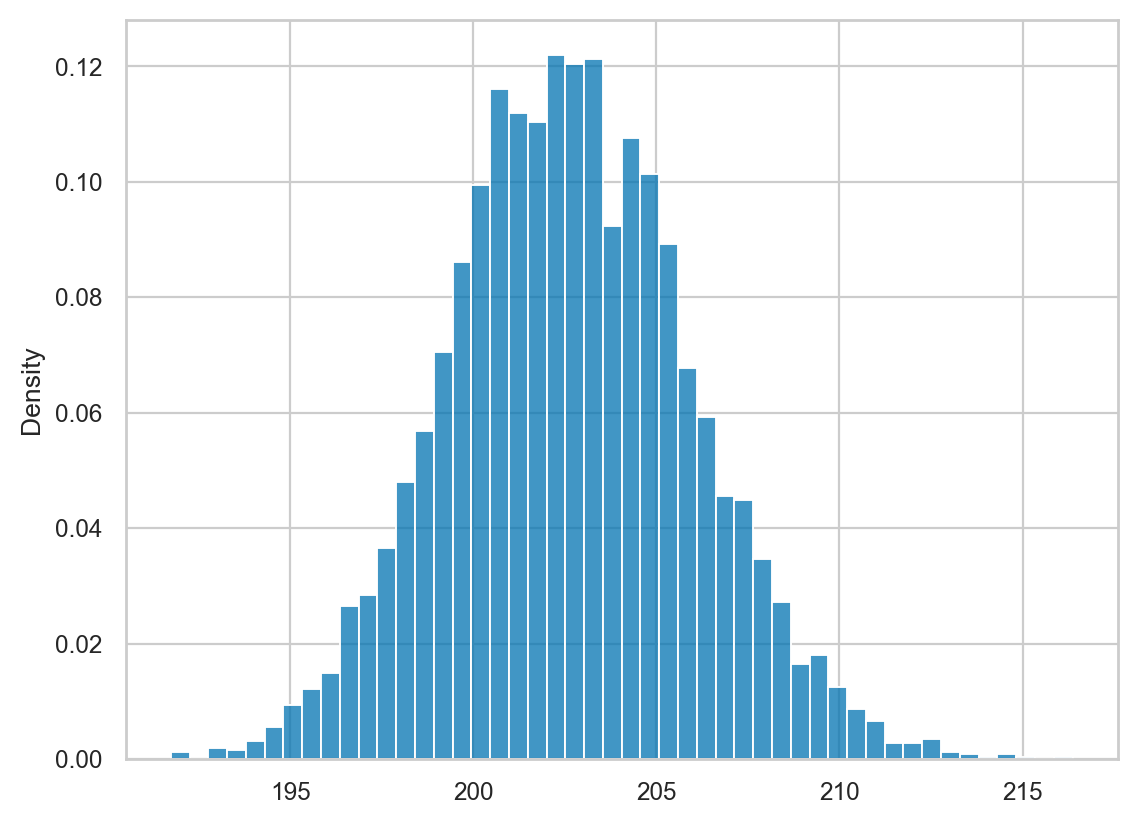

In [35]:
from ministats import gen_boot_dist

# Set the random seed to a particular value to get a reproducible result
np.random.seed(46)

# Generate the bootstrap distribution of the mean
abars_boot = gen_boot_dist(asample, estfunc=np.mean)

# Plot a histogram of the bootstrap distribution
sns.histplot(abars_boot, stat="density");

In [37]:
# Compute the standard deviation of `abars_boot`
np.std(abars_boot)

3.3281116130856487

The standard error $\stderrhat{\overline{\mathbf{a}}}^* = 3.33$
gives us an indication of the accuracy of the estimate
for the population mean $\overline{\mathbf{a}} \approx \mu_A$.
We can write our estimate plus or minus the \emph{margin of error}
$\overline{\mathbf{a}} \pm \stderrhat{\overline{\mathbf{a}}}^* = 202.6 \pm 3.33$.

### E3.8

Compute bootstrap distribution for the sample mean from Batch 04 of the kombucha dataset,
and plot a histogram.
Do you think Batch 04 is a regular batch or an irregular batch of production?

In [38]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample04 = kombucha[kombucha["batch"]==4]["volume"]
ksample04.mean()

1003.8335

The mean of computed from the sample 04 is $\overline{\mathbf{x}}_{04} = 1003.8335$,
which is higher than expected from a regular batch ($\mu_K = 1000$).

In [40]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(47)

# Generate the bootstrap distribution of the mean
kbars04_boot = gen_boot_dist(ksample04, estfunc=np.mean)

# Compute the standard deviation of `kbars04_boot`
np.std(kbars04_boot)

1.2364488755043346

In [41]:
# How far is the sample mean from the expected mean mu_K = 1000 ?
(ksample04.mean() - 1000) / np.std(kbars04_boot)

3.100411247037055

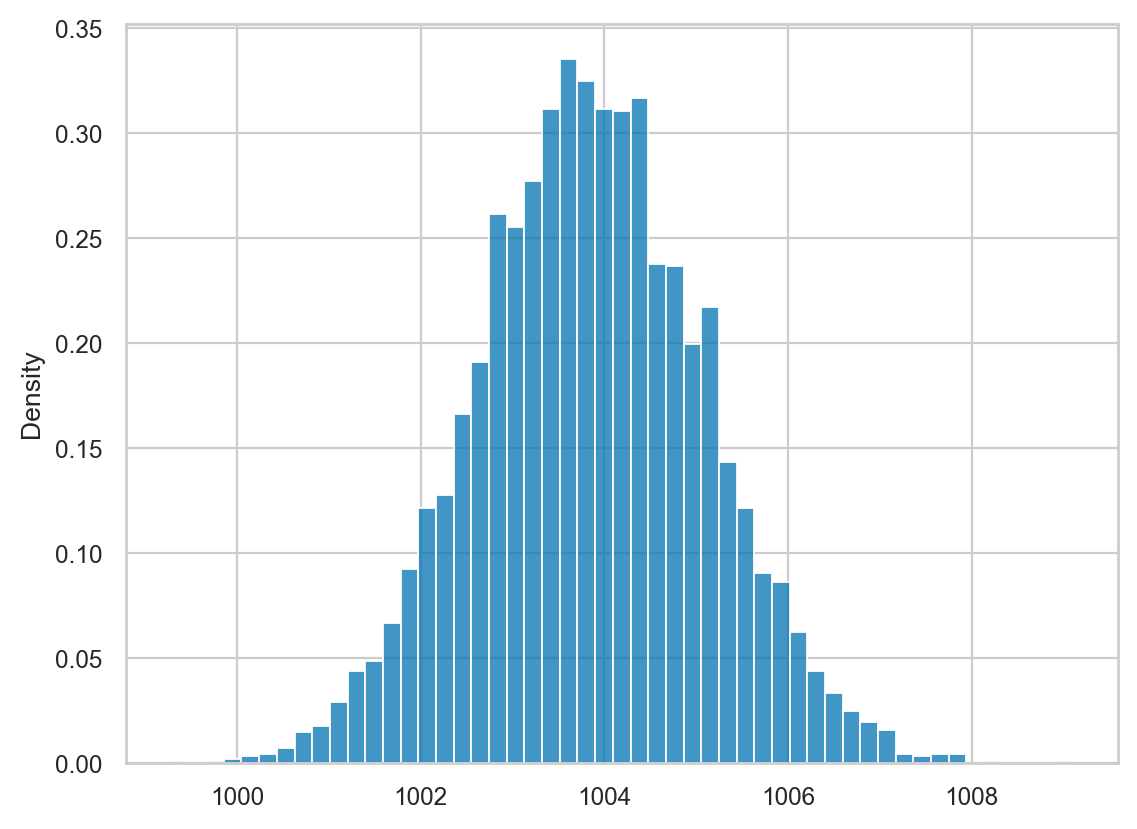

In [42]:
# Plot a histogram of the bootstrap distribution
sns.histplot(kbars04_boot, stat="density");

When we take into account of the possible variability
in the estimate $\overline{\mathbf{k}}_{04} = 1003.8$,
we see that it is very far from the expected mean $\mu_K = 1000$.
This means the Batch 04 is likely not regular batch:
the volume in this batch is higher than expected for regular batches $\mu_K = 1000$.

## Exercises 4

### E3.9

Describe your uncertainty about the unknown population mean $\mu_A$
based on sample of apple weights from the apples dataset `datasets/apples.csv`:  

**a)** Describe the uncertainty about $\mu_A$
by generating the bootstrap distribution from the sample $\mathbf{a}$.   
**b)** Describe the uncertainty using Student's $t$-distribution
centred at $\overline{\mathbf{a}}$,
with scale $\stderrhat{\overline{\mathbf{a}}} = \frac{s_{\mathbf{a}}}{\sqrt{n}}$,
and $\nu = n -1$ degrees of freedom.   
**c)** Compare your answers from part **a)** and **b)** graphically.

In [43]:
apples = pd.read_csv("datasets/apples.csv")
asample = apples["weight"]

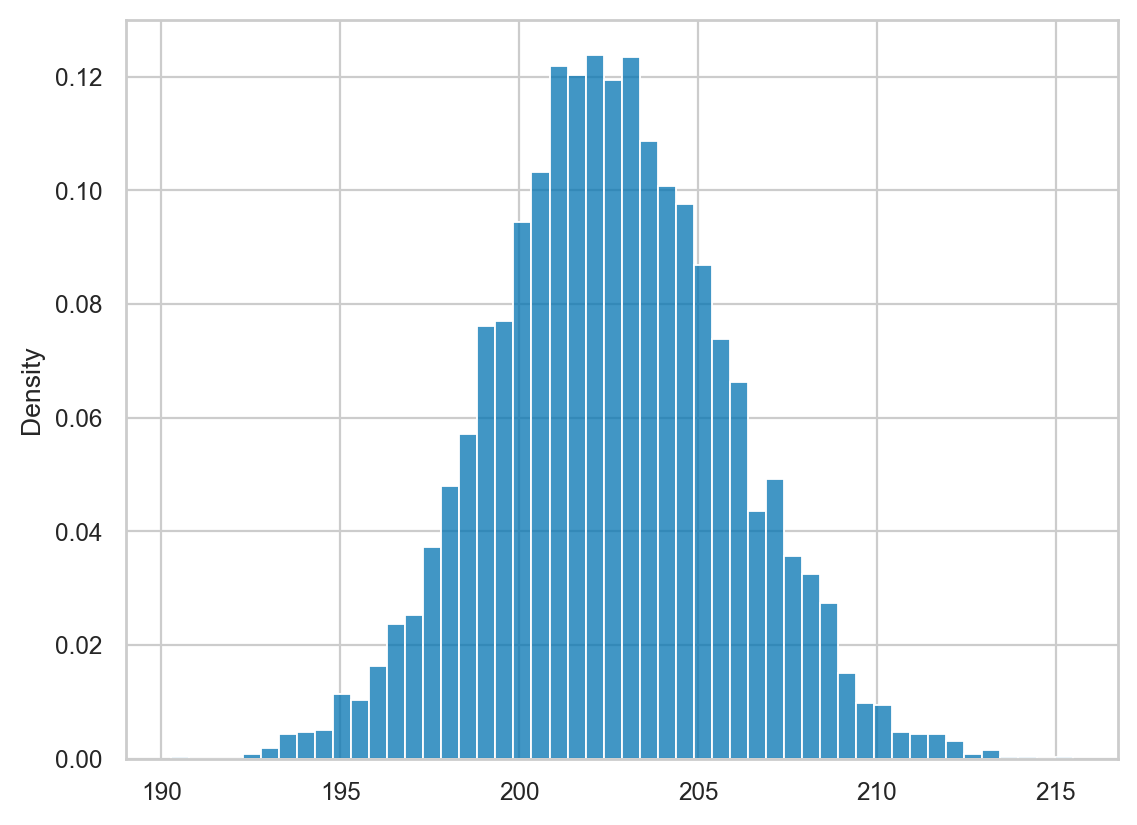

In [45]:
# a)
# Obtain the bootstrap distribution of the mean
abars_boot = gen_boot_dist(asample, estfunc=np.mean)

# Plot a histogram of the bootstrap distribution
sns.histplot(abars_boot, stat="density");

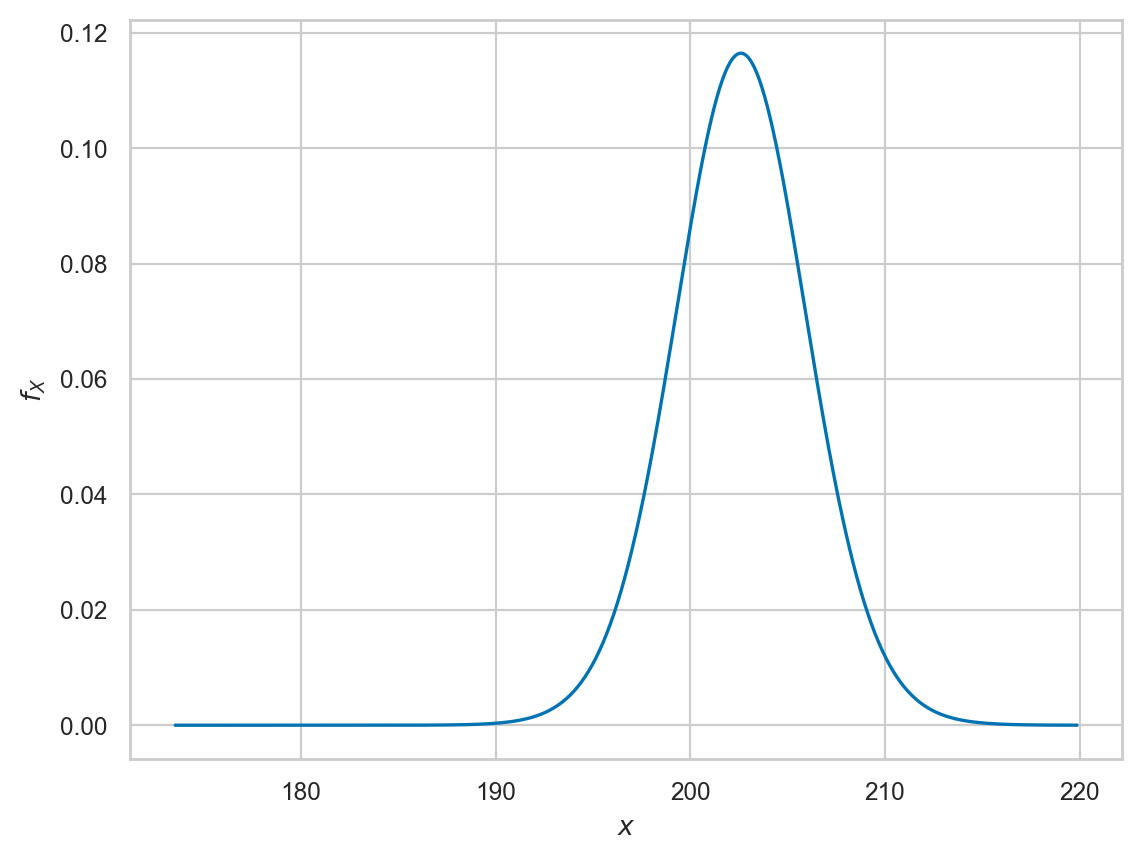

In [47]:
# b) 
# Calculate the estimated standard error
n = len(asample)
sehatAbar = asample.std() / np.sqrt(n)

# Build a model for the uncertainty in the population mean
from scipy.stats import t as tdist
df = n-1
loc = asample.mean()
scale = sehatAbar
rvTAbar = tdist(df, loc=loc, scale=scale)

# Plot the PDF of the model `rvTAbar`
from ministats import plot_pdf
ax = plot_pdf(rvTAbar)

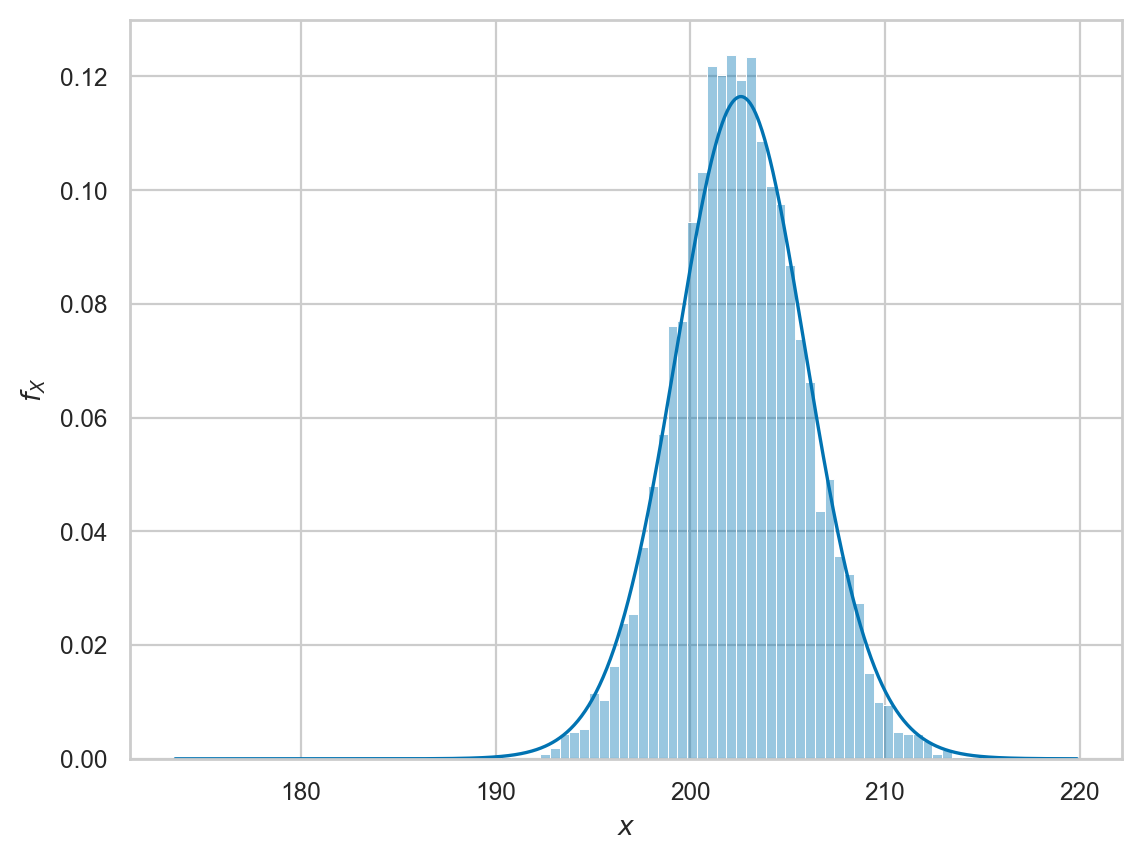

In [49]:
# c) Plot of the PDF of the analytical model
#    and the bootstrap distribution on the same axis
ax = plot_pdf(rvTAbar)
sns.histplot(abars_boot, stat="density", ax=ax, alpha=0.4);

## Exercises 5

### E3.10

Under regular operations,
the kombucha volume is described by the model `rvK`  $= K \sim \mathcal{N}(1000,10)$ .  
**a)** Plot the probability density function for the sampling distribution of the variance for samples of size $n=40$ from the population $K$ .  
**b)** Compute the sample variance of Batch 08 from the kombucha dataset.  
**c)** Compare the observed value in **b)** to the sampling distribution in **a)**.
Does it look like this is a regular batch or irregular batch?

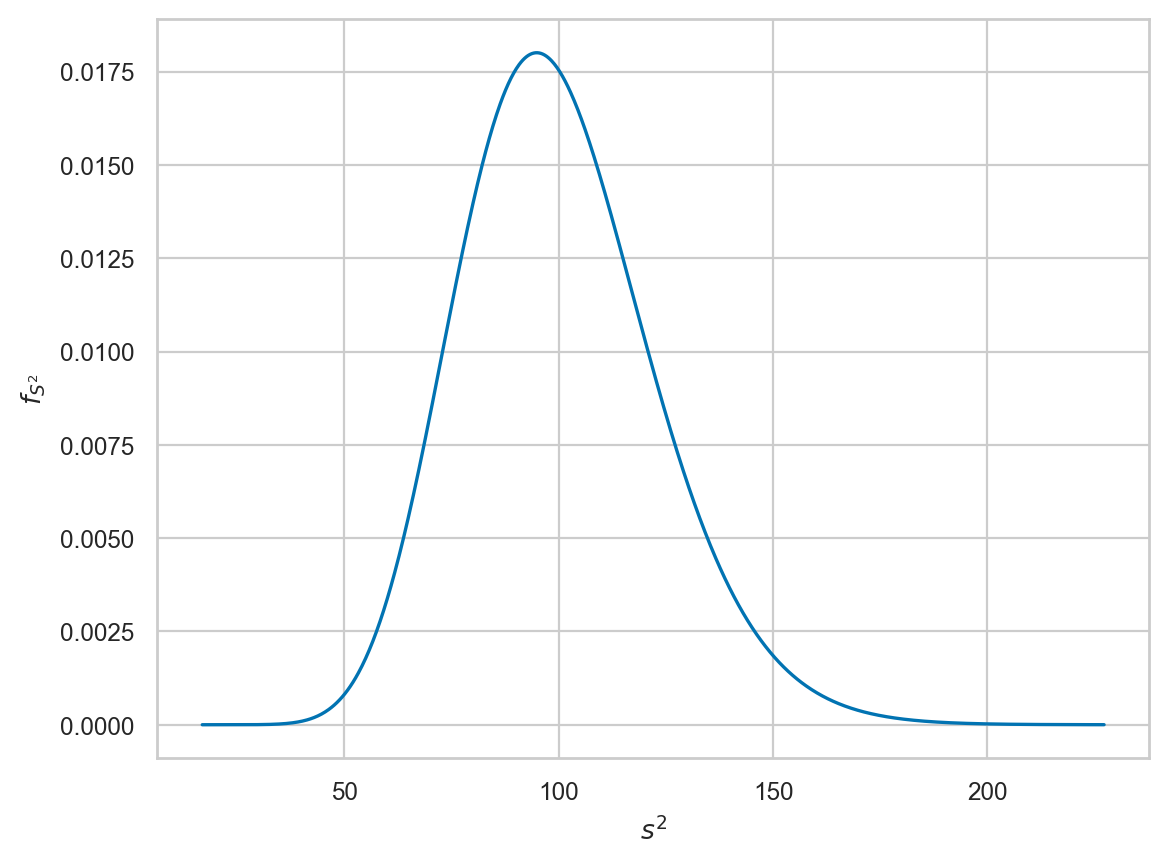

In [51]:
# a) Build an analytical model for the sampling distribution of the variance
sigmaK = 10  # population standard deviation
from scipy.stats import chi2
n = 40
df = n - 1
scale = sigmaK**2 / (n-1)
rvS2 = chi2(df, loc=0, scale=scale)

# Plot the PDF of `rvS2`
from ministats import plot_pdf
plot_pdf(rvS2, rv_name="S^2");

In [53]:
# b) Compute the sample variance of Batch 04
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = kombucha[kombucha["batch"]==8]["volume"]
ksample08.var()

169.99792205128236

**c)** The observed value $s_{\mathbf{k}_{08}}^2 = 170$ is very unlikely to occur
under the expected sampling distribution for the sample variance
for regular batches.
This suggests that Batch 08 is an irregular batch with abnormally high variance.
Better check the machines!

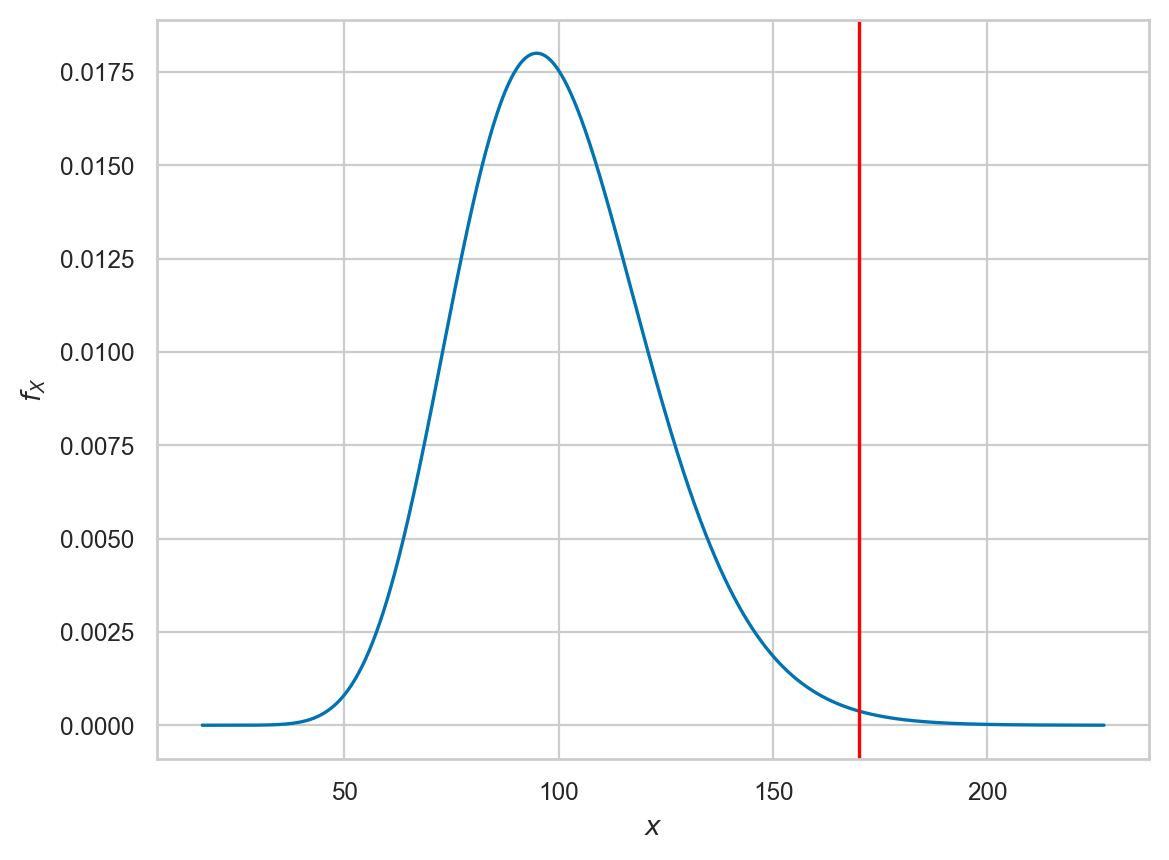

In [54]:
# Plot a vertical line at the observed variance
ax = plot_pdf(rvS2)
ax.axvline(ksample08.var(), color="red");

### E3.11

Compute the bootstrap approximation for sampling distribution of the variance
from Batch 08 of the kombucha dataset.
Plot a histogram.

In [55]:
# Define the variance estimator function
def var(sample):
    xbar = sum(sample) / len(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return sumsqdevs / (len(sample)-1)

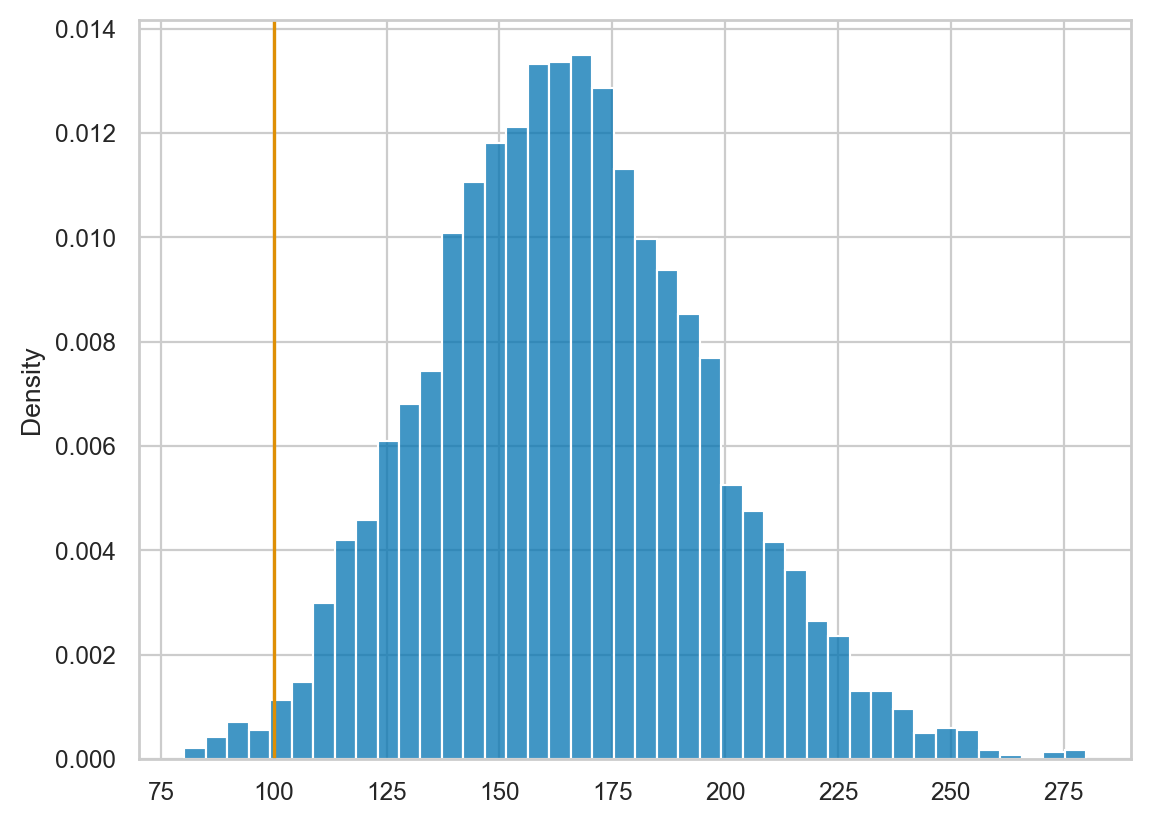

In [57]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = kombucha[kombucha["batch"]==8]["volume"]

# Generate the bootstrap distribution of the variance
kvars08_boot = gen_boot_dist(ksample08, estfunc=var, B=5000)

# Plot a histogram of the bootstrap distribution `kvars08_boot`
ax = sns.histplot(kvars08_boot, stat="density")

# Plot a vertical line at the expected variance
ax.axvline(100, color="C1");

The bootstrap estimates we observe are very far from the 
expected standard deviation for regular batches,
which is $\sigma_K^2 = 100$,
which tells us Batch 08 might be irregular (abnormally high variance).

## Exercises 6

### E3.12

Describe the uncertainty about the difference between means `dmeans(scoresR,scoresU)`,
where `scoresR` and `scoresU` are sleep scores of the rural and urban doctors
from the doctors dataset `datasets/doctors.csv`.  
**a)** Find an analytical formula in terms Student's $t$-distribution.  
**b)** Use bootstrap estimation.  
**c)** Compare your answers from part a) and b) graphically.

In [58]:
doctors = pd.read_csv("datasets/doctors.csv")
scoresR = doctors[doctors["loc"]=="rur"]["score"]
scoresU = doctors[doctors["loc"]=="urb"]["score"]

# observed value
dscores = scoresR.mean() - scoresU.mean()
dscores

6.992885375494076

Estimated standard error 3.5671565854251948


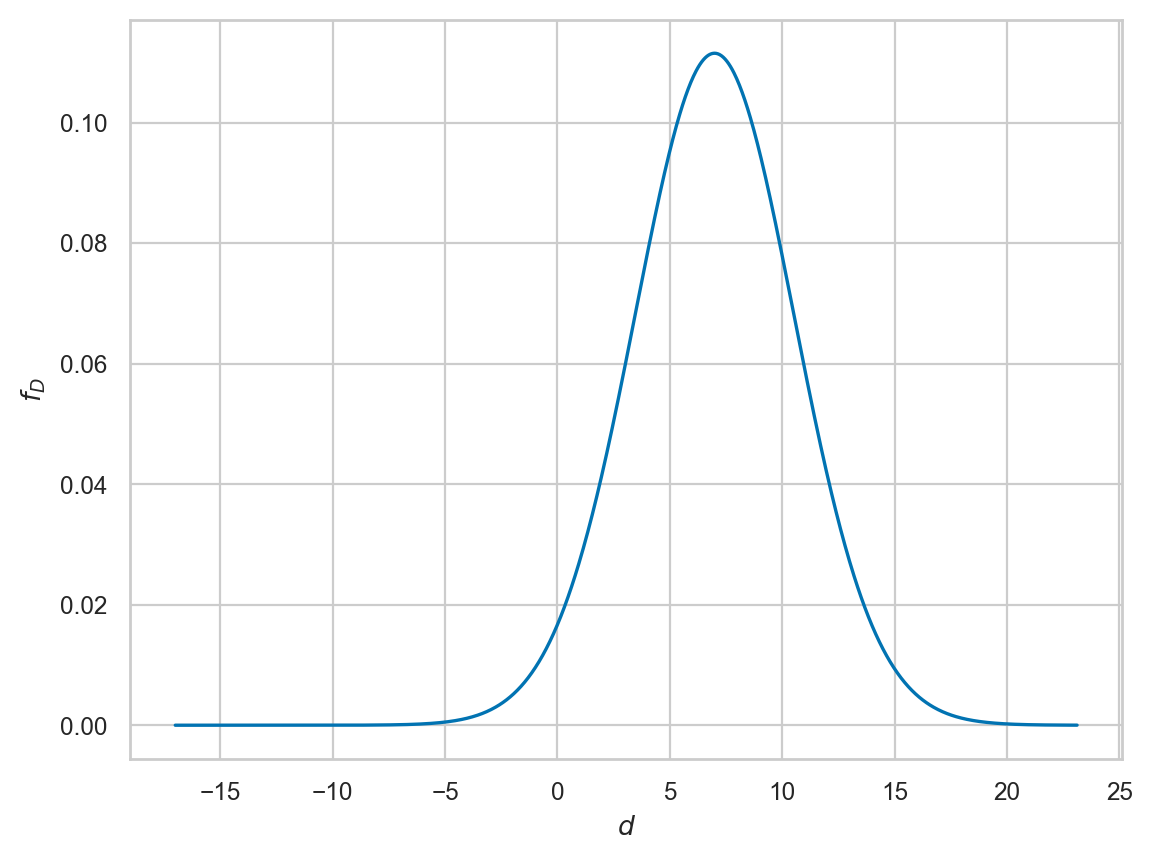

In [60]:
# a) Analytical approximation

# Obtain the sample sizes and stds for the two groups
nR = len(scoresR)
stdR = scoresR.std()
nU = len(scoresU)
stdU = scoresU.std()

# Compute the standard error of the difference between means
seDhatscores = np.sqrt(stdU**2/nU + stdR**2/nR)
print("Estimated standard error", seDhatscores)

# Calculate the degrees of freedom parameter
from ministats import calcdf
df = calcdf(stdU, nU, stdR, nR)

# Build a probability model based on Student's t-distribution
from scipy.stats import t as tdist
rvDscores = tdist(df, loc=dscores, scale=seDhatscores)

# Plot the PDF of the sampling distribution `rvDscores`
from ministats import plot_pdf
plot_pdf(rvDscores, rv_name="D");

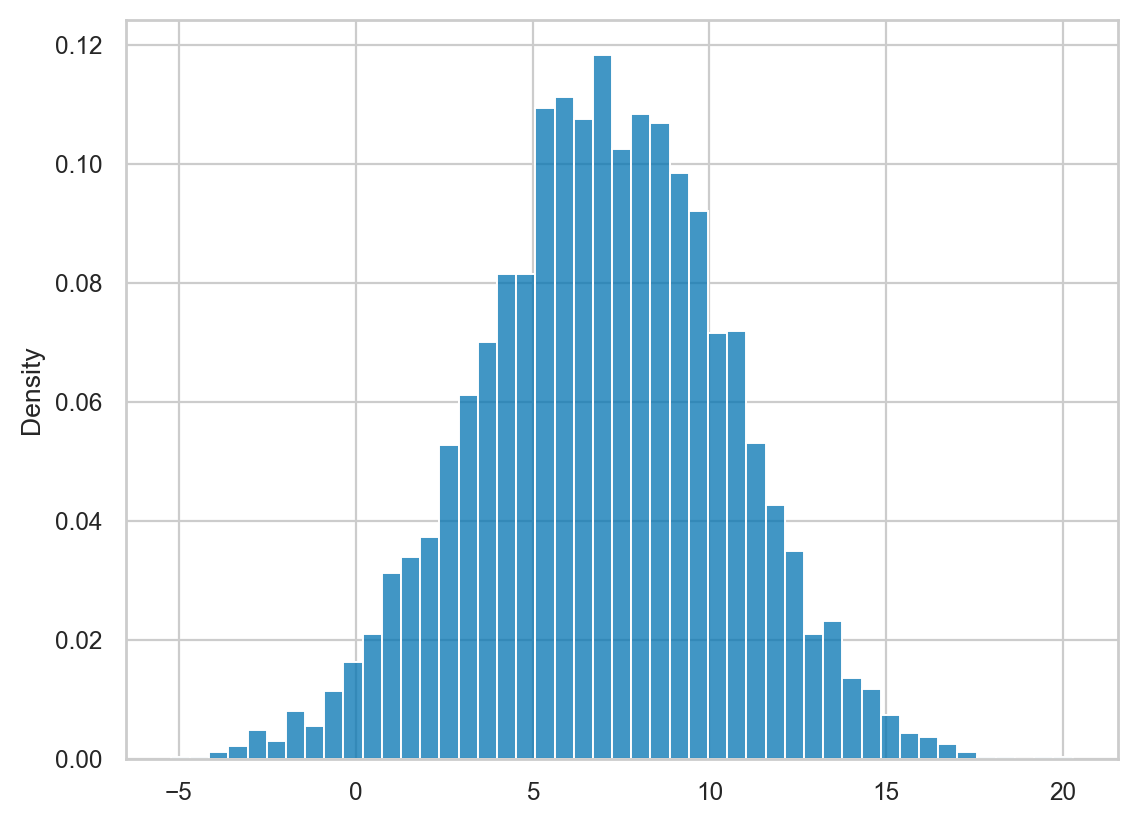

In [62]:
# b) Bootstrap estimate
# Compute bootstrap estimates for mean in each group
from ministats import gen_boot_dist
meanR_boot = gen_boot_dist(scoresR, estfunc=np.mean)
meanU_boot = gen_boot_dist(scoresU, estfunc=np.mean)

# Compute the difference between means of the bootstrap samples
dmeans_boot = np.subtract(meanR_boot, meanU_boot)

# Plot a histogram of the bootstrap distribution
sns.histplot(dmeans_boot, stat="density");

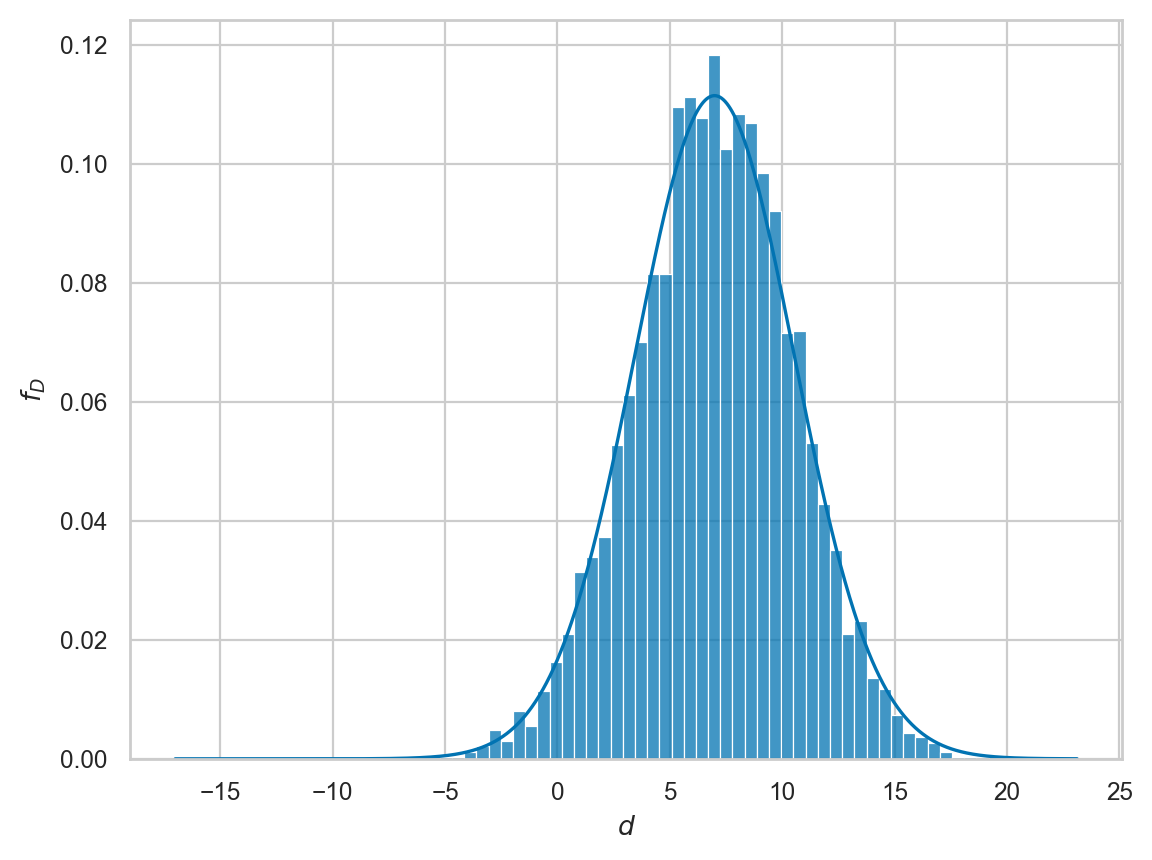

In [64]:
# c) Plot of the PDF of the analytical model
#    and the bootstrap distribution on the same axis
ax = plot_pdf(rvDscores, rv_name="D")
sns.histplot(dmeans_boot, ax=ax, stat="density");

## Exercises 7


### E3.13

Generate the sampling distribution of the median for samples of size $n=30$ from the population $K \sim \mathcal{N}(1000,10)$ .

In [65]:
# Create a computer model for the kombucha population
from scipy.stats import norm
rvK = norm(1000, 10)

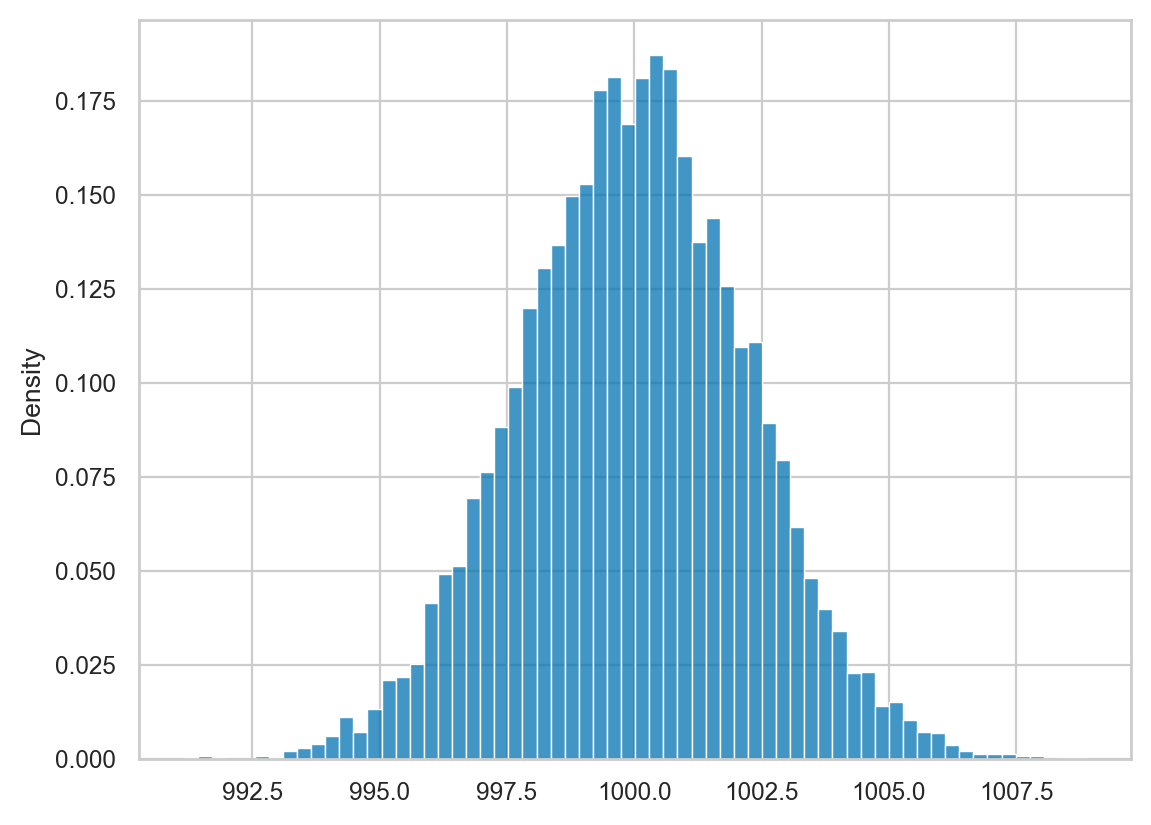

In [67]:
# Compute the sampling distribution of the median (`np.median`)
# for samples of size n=30 from `rvK`
from ministats import gen_sampling_dist
kmedians30 = gen_sampling_dist(rvK, estfunc=np.median, n=30)

# Plot a histogram of the sampling distribution
sns.histplot(kmedians30, stat="density");

In [69]:
# Compute the standard error of the sampling distribution of the median
np.std(kmedians30)

2.243166901483397

### E3.14

Generate the sampling distribution of `P90` , the 90th percentile estimator,
from samples of size $n=30$ from `rvK`  $= K \sim \mathcal{N}(1000,10)$ .
Calculate the standard error $\stderr{\tt{P90}}$ of the estimator.

In [70]:
# Create a computer model for the kombucha population
from scipy.stats import norm
rvK = norm(1000, 10)

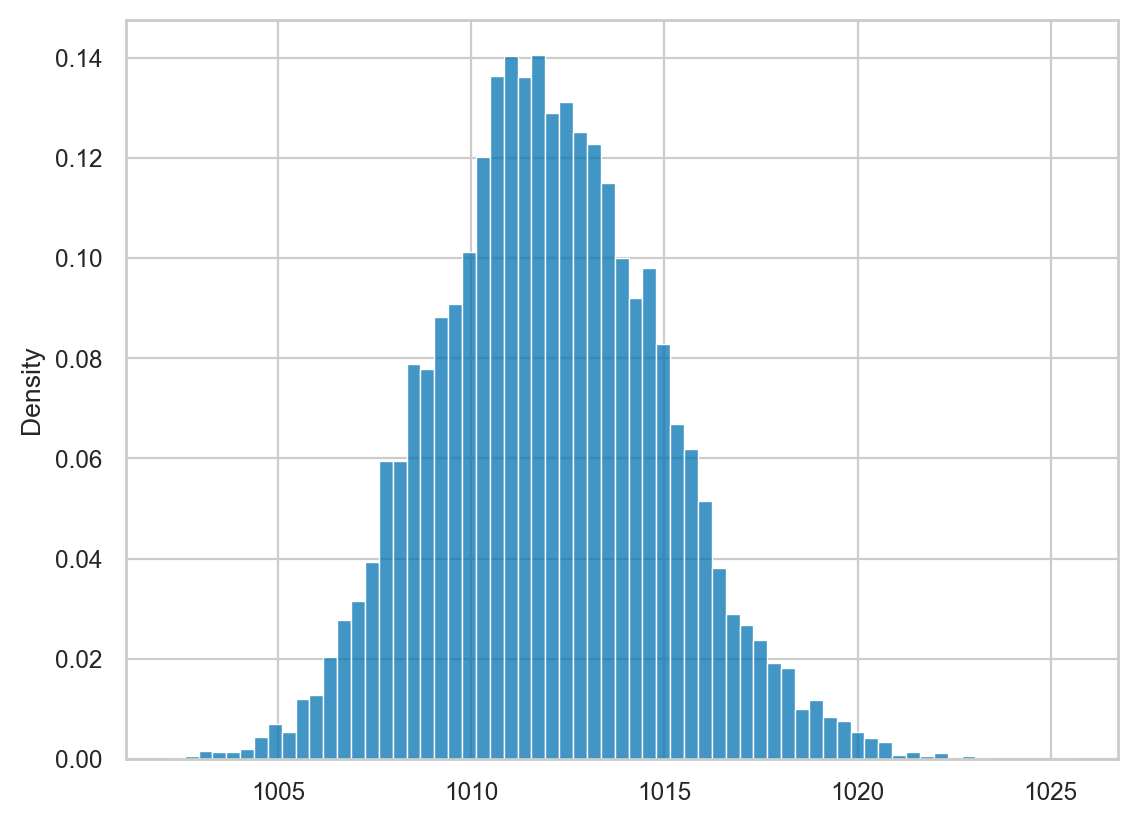

In [72]:
# Define the 90th percentile estimator function
def p90(sample):
    return np.percentile(sample, 90)

# Generate the sampling distribution of the `p90`
# for samples of size n=30 from the kombucha population
kp90s30 = gen_sampling_dist(rvK, estfunc=p90, n=30)

# Plot a histogram of the sampling distribution
sns.histplot(kp90s30, stat="density");

In [74]:
# Compute the standard error of the P90 sampling distribution
np.std(kp90s30)

2.9378410135174584

### E3.15

see text

### E3.16

Use the function `scipy.stats.boostrap` to compute the bootstrap distribution
of the variance from the sample `ksample08`.

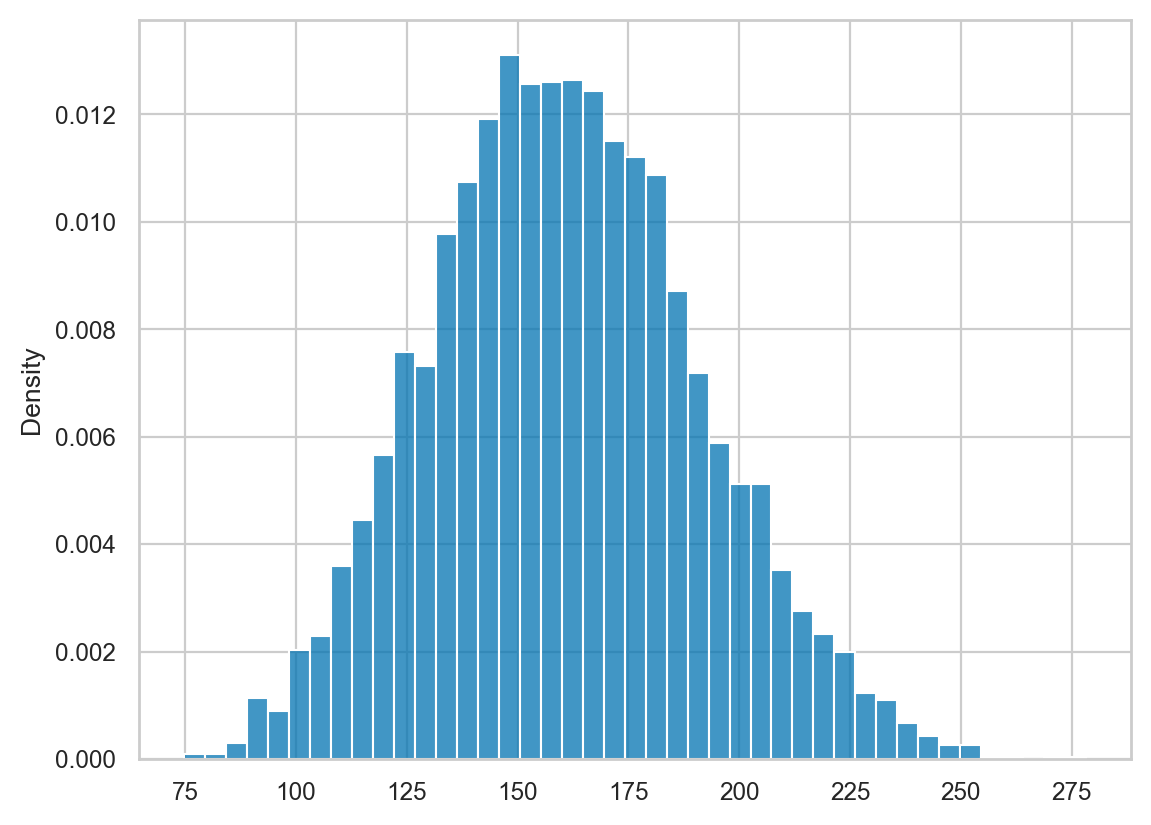

In [76]:
# Select the volume measurements from Batch 08
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = kombucha[kombucha["batch"]==8]["volume"]

# Set the random seed to a particular value to get a reproducible result
np.random.seed(49)

# Call the function scipy.stats.bootstrap
from scipy.stats import bootstrap
res = bootstrap([ksample08], statistic=np.var,
                n_resamples=5000, vectorized=False)

# Plot a histogram of the sampling distribution
sns.histplot(res.bootstrap_distribution, stat="density");

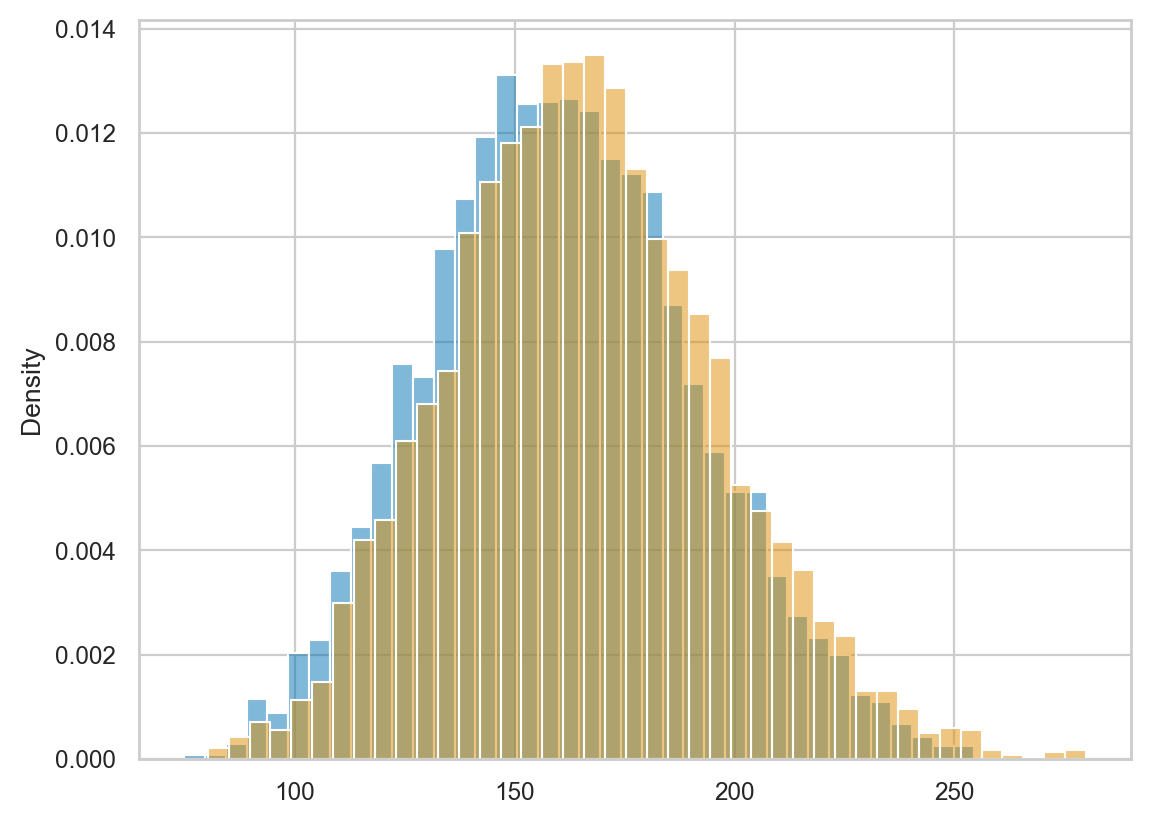

In [78]:
# Plot the bootstrap distribution obtained from scipy.stats.bootstrap
# and the bootstrap distribution `kvars08_boot` we obtained earlier.
ax = sns.histplot(res.bootstrap_distribution, stat="density", alpha=0.5)
sns.histplot(kvars08_boot, ax=ax, stat="density", color="C1", alpha=0.5);